In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Supervised_Learning_Messy_Customer_Churn.csv")
df.shape

(184, 13)

In [4]:
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [5]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    object 
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    object 
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    object 
 9   Payment_Method         184 non-null    object 
 10  Region                 184 non-null    object 
 11  Plan_Type              184 non-null    object 
 12  Churn                  184 non-null    object 
dtypes: float64(6), object(7)
memory usage: 18.8+ KB


In [7]:
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

In [8]:
df['Annual_Income'].dtype

dtype('float64')

In [9]:
df.describe()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,1.720000e+02,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,1.218552e+05,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,7.579821e+05,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,-1.200000e+04,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,4.860000e+04,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,6.440000e+04,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,7.797500e+04,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,9.999999e+06,150.000000,999.000000,30.000000,44.000000,15.000000


In [10]:
df["Churn"].value_counts()

Churn
Yes    97
No     87
Name: count, dtype: int64

In [11]:
df["Customer_ID"].value_counts()

Customer_ID
CUST-1043    2
CUST-1110    2
CUST-1008    2
CUST-1152    2
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-1103    1
Name: count, Length: 180, dtype: int64

In [12]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

In [13]:
df.isnull().sum().sum()

np.int64(50)

In [14]:
df.duplicated().sum()

np.int64(4)

In [15]:
df['Customer_ID'].duplicated().sum()

np.int64(4)

In [16]:
df[df.duplicated(keep=False)].sort_values('Customer_ID').head(10)

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [17]:
numeric_cols = ['Age','Annual_Income','Tenure_Months','Monthly_Charges',
                'Support_Calls_Last_3M','Data_Usage_GB','Satisfaction_Score']

In [18]:
num_cols = df.select_dtypes(exclude=['object']).columns
print(num_cols)

Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score'],
      dtype='object')


In [19]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type',
       'Churn'],
      dtype='object')


In [20]:
df["Contract_Type"].value_counts()

Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

In [21]:
df['Contract_Type'] = df['Contract_Type'].replace('?', pd.NA)

df['Contract_Type'] = (
    df['Contract_Type']
    .str.strip()
    .str.lower()
    .replace({
        'monthly': 'Monthly',
        '1 year': '1 Year',
        '2 year': '2 Year',
        '2-year': '2 Year'
    })
)
df["Contract_Type"].value_counts()

Contract_Type
Monthly    106
1 Year      53
2 Year      24
Name: count, dtype: int64

In [22]:
df['Contract_Type'] = df['Contract_Type'].fillna(df['Contract_Type'].mode()[0])

In [23]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

In [24]:
df["Payment_Method"] = df["Payment_Method"].str.strip().str.title()
df["Payment_Method"].value_counts()


Payment_Method
Bank Transfer    49
Upi              47
Credit Card      44
Debit Card       42
?                 1
Unknown           1
Name: count, dtype: int64

In [25]:
df["Payment_Method"] = df["Payment_Method"].replace("?", np.nan)

In [26]:
df["Payment_Method"] = df["Payment_Method"].fillna(df["Payment_Method"].mode()[0])

In [27]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    50
Upi              47
Credit Card      44
Debit Card       42
Unknown           1
Name: count, dtype: int64

In [28]:
df["Region"].value_counts()

Region
South     50
North     49
West      47
East      34
west       1
NORTH      1
?          1
south      1
Name: count, dtype: int64

In [29]:
df["Region"] = df["Region"].str.strip().str.title()
df["Region"].value_counts()

Region
South    51
North    50
West     48
East     34
?         1
Name: count, dtype: int64

In [30]:
df["Region"] = df["Region"].replace("?", np.nan)

In [31]:
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

In [32]:
df["Region"].value_counts()

Region
South    52
North    50
West     48
East     34
Name: count, dtype: int64

In [33]:
df["Plan_Type"].value_counts()

Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

In [34]:
df["Plan_Type"] = df["Plan_Type"].str.strip().str.title()
df["Plan_Type"].value_counts()

Plan_Type
Standard    94
Basic       49
Premium     41
Name: count, dtype: int64

In [35]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      1
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            7
Satisfaction_Score       0
dtype: int64


In [36]:
numeric_cols = df.select_dtypes(include="number")
negative_rows = df[(numeric_cols < 0).any(axis=1)]
negative_rows

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
45,CUST-1105,34.0,35800.0,60.0,118.63,3.0,-0.8,7.0,2 Year,Upi,East,Standard,No
63,CUST-1079,NaN,53100.0,29.0,83.71,3.0,-1.6,5.0,Monthly,Upi,North,Basic,Yes
77,CUST-1033,36.0,57800.0,72.0,50.61,3.0,-1.1,1.0,Monthly,Credit Card,North,Standard,Yes
95,CUST-1143,20.0,-11500.0,2.0,57.34,NaN,19.4,2.0,1 Year,Credit Card,West,Standard,No
112,CUST-1062,34.0,-12000.0,29.0,60.69,4.0,18.9,4.0,Monthly,Upi,East,Basic,Yes
120,CUST-1124,22.0,50100.0,57.0,93.56,3.0,-0.3,9.0,Monthly,Upi,South,Standard,No
144,CUST-1018,-5.0,75900.0,64.0,137.15,5.0,14.2,5.0,Monthly,Upi,North,Premium,Yes
177,CUST-1021,51.0,100400.0,14.0,51.52,2.0,-2.0,1.0,2 Year,Upi,South,Premium,No
178,CUST-1072,51.0,NaN,38.0,77.19,5.0,-10.0,5.0,Monthly,Credit Card,West,Standard,No


In [37]:
df["Age"] = df["Age"].mask(df["Age"] < 0, np.nan)
df["Data_Usage_GB"] = df["Data_Usage_GB"].mask(
    df["Data_Usage_GB"] < 0, np.nan
)

In [38]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Data_Usage_GB"] = df["Data_Usage_GB"].fillna(
    df["Data_Usage_GB"].median()
)

In [39]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      0
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [40]:
median_income = df.loc[df['Annual_Income'] >= 0, 'Annual_Income'].median()
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = median_income
print("Negative values:", (df['Annual_Income'] < 0).sum())
print("Median used:", median_income)

Negative values: 0
Median used: 64700.0


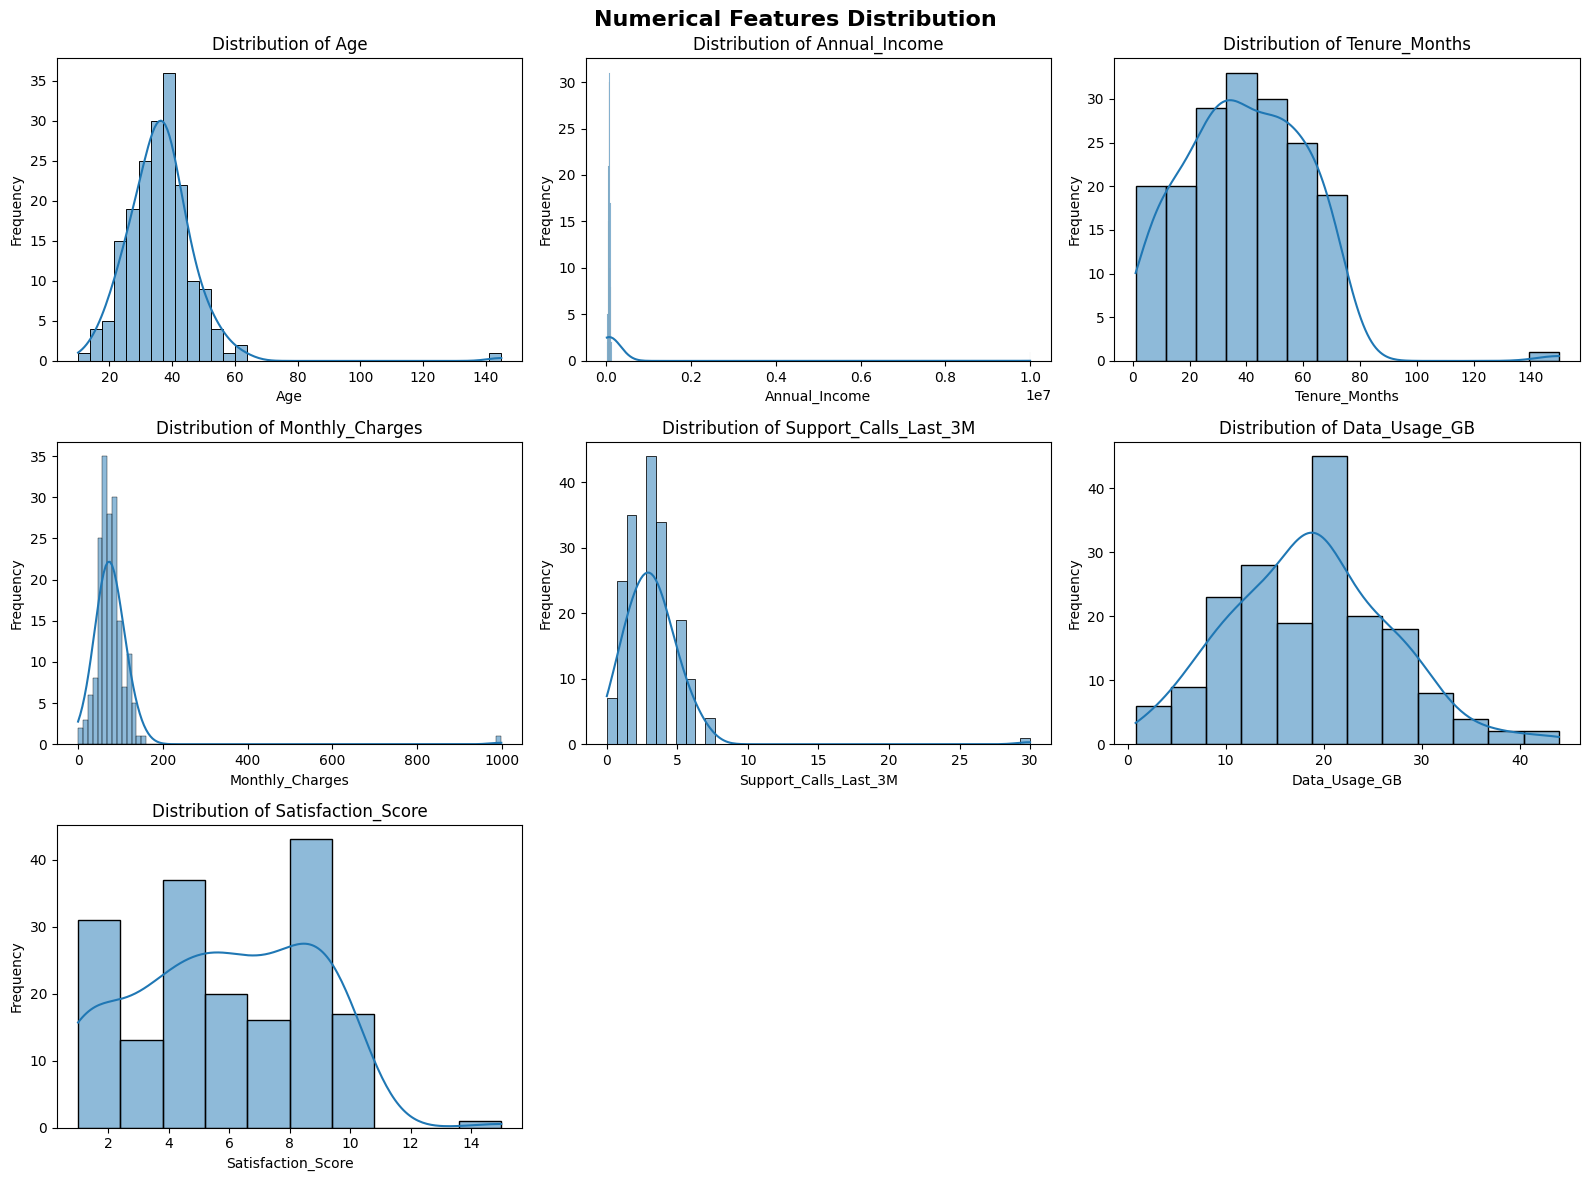

In [41]:
numeric_cols = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    "Numerical Features Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [42]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()
correlation

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.005074,0.032331,0.005018,-0.021513,-0.029712,-0.051955
Annual_Income,0.005074,1.000000,-0.127055,0.011238,0.025034,-0.120125,0.087546
Tenure_Months,0.032331,-0.127055,1.000000,-0.006854,-0.040394,0.034958,0.005583
Monthly_Charges,0.005018,0.011238,-0.006854,1.000000,0.021635,0.001403,0.105330
Support_Calls_Last_3M,-0.021513,0.025034,-0.040394,0.021635,1.000000,-0.036642,-0.031787
Data_Usage_GB,-0.029712,-0.120125,0.034958,0.001403,-0.036642,1.000000,0.042551
Satisfaction_Score,-0.051955,0.087546,0.005583,0.105330,-0.031787,0.042551,1.000000


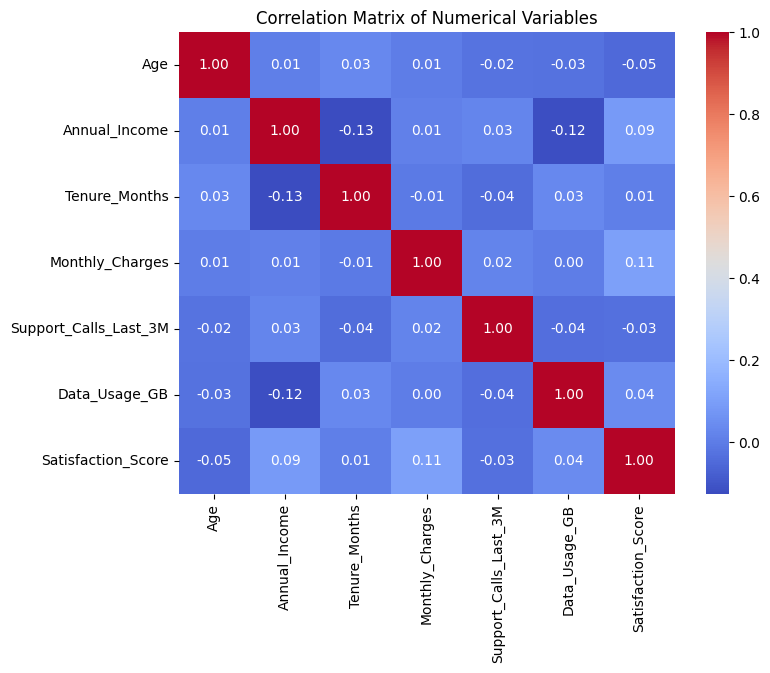

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [44]:
numeric_cols = df.select_dtypes(include="number")
for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}")
    print(f"Lower limit: {lower}")
    print(f"Upper limit: {upper}")
    print(f"Number of outliers: {len(outliers)}")


Age
Lower limit: 13.5
Upper limit: 57.5
Number of outliers: 5

Annual_Income
Lower limit: 6912.5
Upper limit: 120612.5
Number of outliers: 2

Tenure_Months
Lower limit: -20.0
Upper limit: 100.0
Number of outliers: 1

Monthly_Charges
Lower limit: 9.292500000000011
Upper limit: 138.8725
Number of outliers: 4

Support_Calls_Last_3M
Lower limit: -1.0
Upper limit: 7.0
Number of outliers: 1

Data_Usage_GB
Lower limit: -3.3125000000000036
Upper limit: 40.587500000000006
Number of outliers: 2

Satisfaction_Score
Lower limit: -2.0
Upper limit: 14.0
Number of outliers: 1


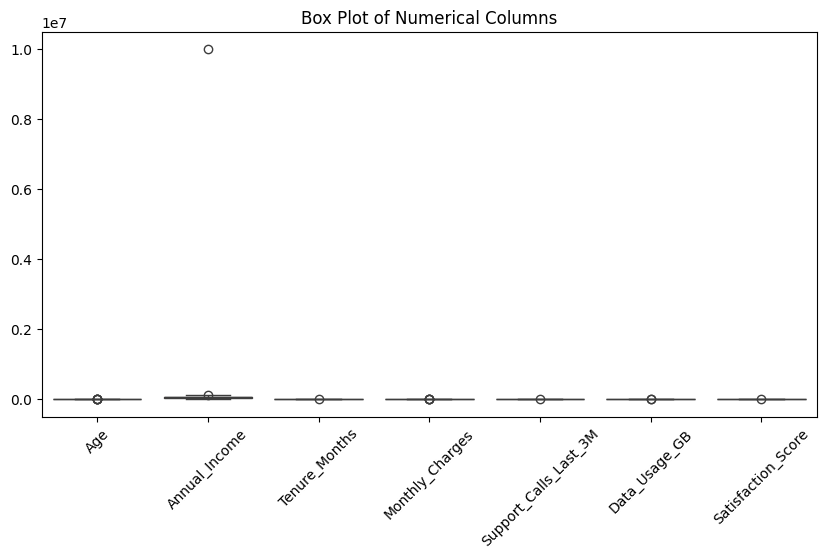

In [45]:
numeric_cols = df.select_dtypes(include="number")
plt.figure(figsize=(10, 5))
sns.boxplot(data=numeric_cols)
plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Columns")
plt.show()

In [46]:
numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    percentage = (outlier_count / len(df)) * 100
    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")

Age: 5 outliers (2.72%)
Annual_Income: 2 outliers (1.09%)
Tenure_Months: 1 outliers (0.54%)
Monthly_Charges: 4 outliers (2.17%)
Support_Calls_Last_3M: 1 outliers (0.54%)
Data_Usage_GB: 2 outliers (1.09%)
Satisfaction_Score: 1 outliers (0.54%)


In [47]:
numeric_cols = df.select_dtypes(include="number").columns
total_outliers = 0
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    total_outliers += ((df[col] < lower) | (df[col] > upper)).sum()
print("Total outliers:", total_outliers)

Total outliers: 16


In [48]:
total_values = len(df) * len(numeric_cols)
percentage = (total_outliers / total_values) * 100
print(f"Total outliers: {total_outliers}")
print(f"Outlier percentage: {percentage:.2f}%")

Total outliers: 16
Outlier percentage: 1.24%


In [49]:

numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

# Replace invalid values with NaN
df['Age'] = df['Age'].replace([10, 16, 17, 145], pd.NA)

df['Annual_Income'] = df['Annual_Income'].replace([9999999], pd.NA)

df['Tenure_Months'] = df['Tenure_Months'].replace([150], pd.NA)

df['Monthly_Charges'] = df['Monthly_Charges'].replace([0, 999], pd.NA)

df['Support_Calls_Last_3M'] = df['Support_Calls_Last_3M'].replace([30], pd.NA)

df['Satisfaction_Score'] = df['Satisfaction_Score'].replace([15], pd.NA)

# Convert to numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace invalid/missing values with column median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fix capitalization
if 'Payment_Method' in df.columns:
    df['Payment_Method'] = df['Payment_Method'].replace({
        'Upi': 'UPI'
    })

print(df.head())

  Customer_ID   Age  Annual_Income  Tenure_Months  Monthly_Charges  \
0   CUST-1020  22.0        23800.0           11.0            62.96   
1   CUST-1043  35.0        69400.0           17.0            75.63   
2   CUST-1157  55.0        64700.0           49.0            92.85   
3   CUST-1112  36.0        80000.0            9.0            85.67   
4   CUST-1149  41.0        95700.0           51.0            60.77   

   Support_Calls_Last_3M  Data_Usage_GB  Satisfaction_Score Contract_Type  \
0                    7.0           20.4                 5.0       Monthly   
1                    6.0           17.5                 9.0       Monthly   
2                    3.0           21.6                 1.0       Monthly   
3                    0.0           34.3                 9.0       Monthly   
4                    1.0           23.7                 9.0       Monthly   

  Payment_Method Region Plan_Type Churn  
0  Bank Transfer  North  Standard   Yes  
1  Bank Transfer  South     Basi

In [50]:
numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

total_outliers = 0
total_values = 0

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    outlier_count = len(outliers)
    
    total_outliers += outlier_count
    total_values += df[col].count()
    
    print(f"{col}: {outlier_count} outliers")


outlier_percentage = (total_outliers / total_values) * 100

print("\nTotal Outlier Values:", total_outliers)
print("Total Numerical Values:", total_values)
print(f"Overall Outlier Percentage: {outlier_percentage:.2f}%")

Age: 3 outliers
Annual_Income: 3 outliers
Tenure_Months: 0 outliers
Monthly_Charges: 8 outliers
Support_Calls_Last_3M: 0 outliers
Data_Usage_GB: 2 outliers
Satisfaction_Score: 0 outliers

Total Outlier Values: 16
Total Numerical Values: 1288
Overall Outlier Percentage: 1.24%


In [51]:
df.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [52]:
df = df.drop_duplicates()

In [53]:
df.shape

(180, 13)

In [54]:
numeric_cols = df.select_dtypes(include="number").columns
print(df[numeric_cols].median())

Age                         36.000
Annual_Income            64700.000
Tenure_Months               38.000
Monthly_Charges             73.565
Support_Calls_Last_3M        3.000
Data_Usage_GB               18.800
Satisfaction_Score           6.000
dtype: float64


In [55]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [56]:
print(df[numeric_cols].isnull().sum())
print(df[numeric_cols].dtypes)

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
dtype: object


In [57]:
import pandas as pd
import numpy as np

# ==========================================
# 1. BASIC DATASET INFORMATION
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Rows and Columns:", df.shape)
print("\nData Types:")
print(df.dtypes)


# ==========================================
# 2. NULL VALUES
# ==========================================

print("\n" + "=" * 60)
print("NULL VALUES")
print("=" * 60)

null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if len(null_counts) == 0:
    print("No null values found.")
else:
    print(null_counts)
    print("\nTotal null values:", df.isnull().sum().sum())


# ==========================================
# 3. DUPLICATE DATA
# ==========================================

print("\n" + "=" * 60)
print("DUPLICATE DATA")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)])

# ==========================================
# 5. INVALID / NON-NUMERIC DATA
# ==========================================

print("\n" + "=" * 60)
print("INVALID / NON-NUMERIC DATA")
print("=" * 60)

for col in numeric_cols:
    invalid = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    
    if invalid.sum() > 0:
        print(f"\n{col}: {invalid.sum()} invalid values")
        print(df.loc[invalid, col].unique())

print("\nObject/Categorical columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].isna().sum()} null values")


# ==========================================
# 6. VALUE COUNT OF CATEGORICAL DATA
# ==========================================

print("\n" + "=" * 60)
print("CATEGORICAL VALUE COUNTS")
print("=" * 60)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


# ==========================================
# 7. SUMMARY
# ==========================================

print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Total Null Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

DATASET INFORMATION
Rows and Columns: (180, 13)

Data Types:
Customer_ID               object
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object

NULL VALUES
No null values found.

DUPLICATE DATA
Duplicate rows: 0

INVALID / NON-NUMERIC DATA

Object/Categorical columns:
Customer_ID: 0 null values
Contract_Type: 0 null values
Payment_Method: 0 null values
Region: 0 null values
Plan_Type: 0 null values
Churn: 0 null values

CATEGORICAL VALUE COUNTS

--- Customer_ID ---
Customer_ID
CUST-1020    1
CUST-1043    1
CUST-1157    1
CUST-1112    1
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-11

In [58]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", len(categorical_cols))
print(categorical_cols.tolist())

Categorical Columns: 6
['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [59]:
cols = ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']
for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Contract_Type ---
Contract_Type
Monthly    104
1 Year      52
2 Year      24
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
Bank Transfer    47
UPI              47
Credit Card      44
Debit Card       41
Unknown           1
Name: count, dtype: int64

--- Region ---
Region
North    50
South    50
West     46
East     34
Name: count, dtype: int64

--- Plan_Type ---
Plan_Type
Standard    94
Basic       47
Premium     39
Name: count, dtype: int64


In [60]:
numeric_cols = df.select_dtypes(include=np.number).columns
negative_counts = {}
for col in numeric_cols:
    count = (df[col] < 0).sum()
    if count > 0:
        negative_counts[col] = count

if len(negative_counts) == 0:
    print("No negative values found.")
else:
    print("Negative values by column:")
    for col, count in negative_counts.items():
        print(f"{col}: {count}")

No negative values found.


In [61]:
clean_df = df.copy()

In [62]:
print(clean_df.shape)
print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())

(180, 13)
Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64
0


In [63]:
print((clean_df.select_dtypes(include='number') < 0).sum())

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [64]:
clean_df.to_csv("cleaned_customer1.csv", index=False)

### Data preprocessing(unsupervised)

In [65]:
df_cluster = df.drop(columns=["Churn", "Customer_ID"])
df_cluster.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium


In [66]:
numeric_columns = df_cluster.select_dtypes(include=["int", "float"]).columns.tolist()
categorical_columns = df_cluster.select_dtypes(include=["object"]).columns.tolist()
numeric_columns

['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

In [67]:
correlation = df[numeric_columns].corr()

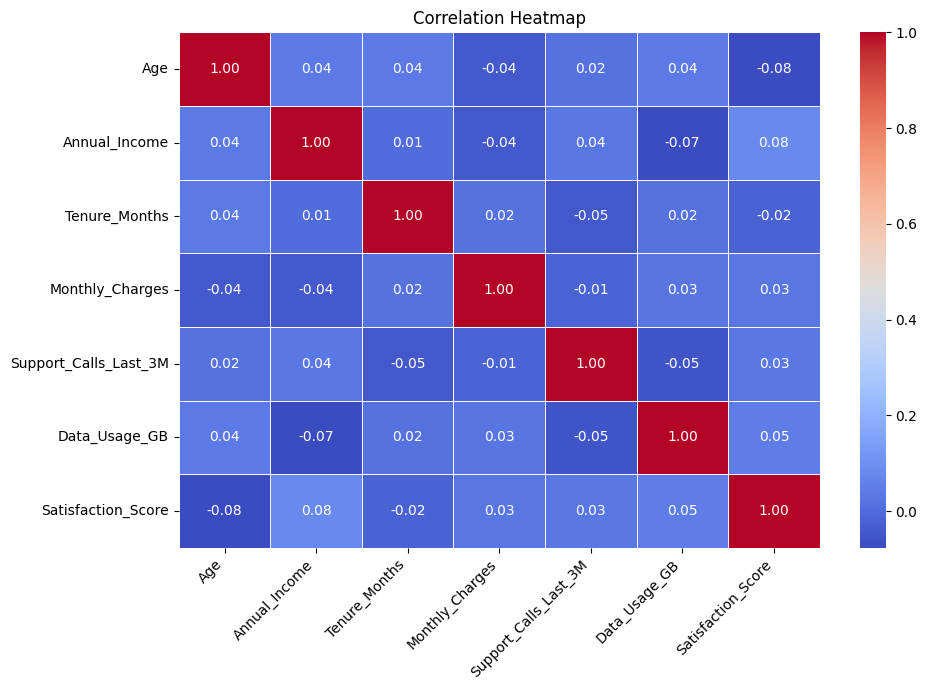

In [68]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

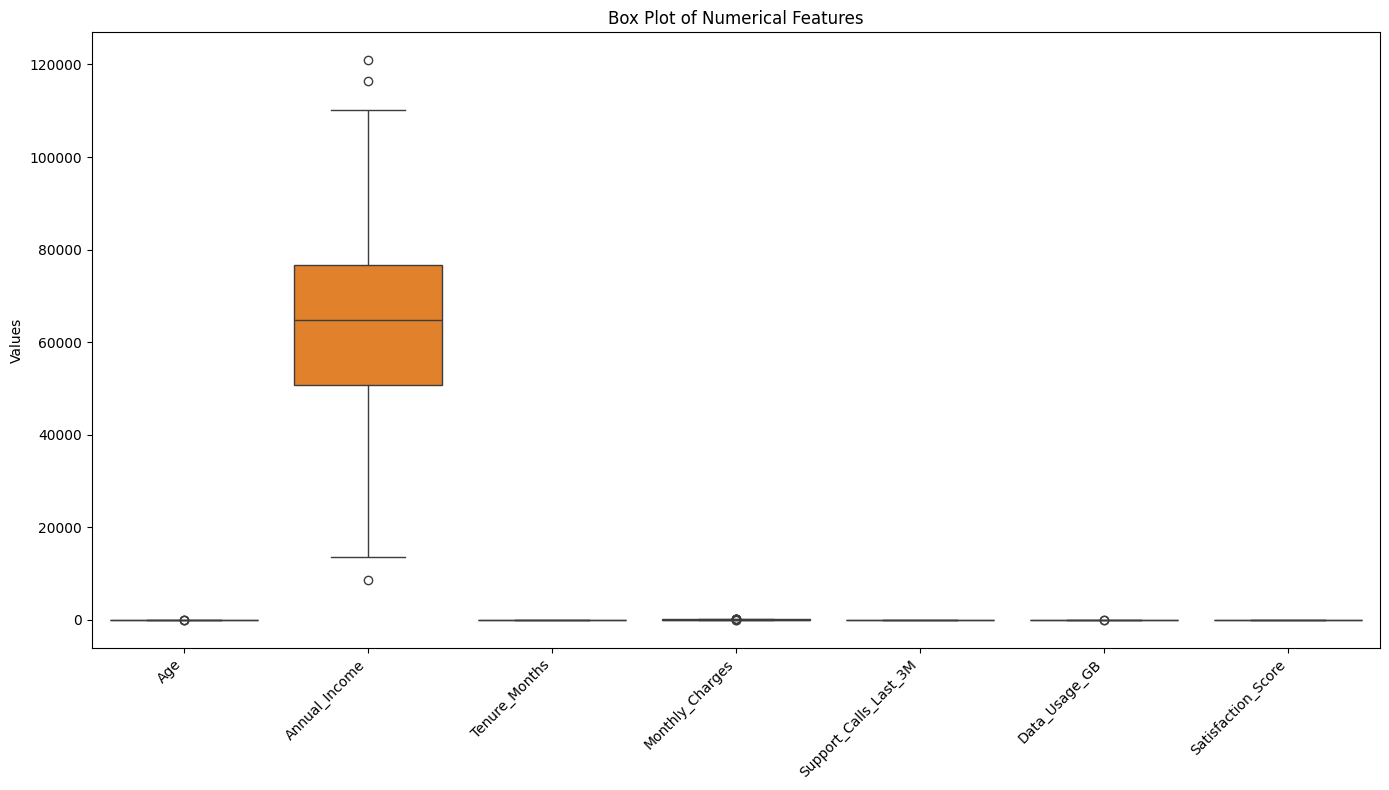

In [69]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numeric_columns])
plt.title('Box Plot of Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [70]:
df_cluster[numeric_columns] = df_cluster[numeric_columns].fillna(
    df_cluster[numeric_columns].median()
)

for column in categorical_columns:
    df_cluster[column] = df_cluster[column].fillna(
        df_cluster[column].mode()[0]
    )
df_cluster.isnull().sum()

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
dtype: int64

### Convert Categorical Features to Numerical Features

Clustering algorithms require numerical input, so categorical variables are converted using one-hot encoding.

In [71]:
df_encoded = pd.get_dummies(
    df_cluster,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)
df_encoded

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,...,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,0,0,1,...,0,1,0,0,0,1,0,0,0,1
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,0,0,1,...,1,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
180,19.0,63000.0,38.0,64.24,1.0,13.0,7.0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
181,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,0,0,1,...,1,0,0,1,0,0,0,0,0,1
182,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,0,0,1,...,0,1,0,1,0,0,0,0,0,1


In [72]:
df_encoded.shape

(180, 22)

### Select Features for Clustering

In [73]:
X = df_encoded.copy()
X.shape

(180, 22)

In [74]:
X.columns

Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score',
       'Contract_Type_1 Year', 'Contract_Type_2 Year', 'Contract_Type_Monthly',
       'Payment_Method_Bank Transfer', 'Payment_Method_Credit Card',
       'Payment_Method_Debit Card', 'Payment_Method_UPI',
       'Payment_Method_Unknown', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Plan_Type_Basic', 'Plan_Type_Premium',
       'Plan_Type_Standard'],
      dtype='object')

### Feature Scaling (Standard)

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.67622814, -1.91652452, -1.43010681, ..., -0.59446065,
        -0.52592371,  0.95650071],
       [-0.15356748,  0.19502507, -1.1195266 , ...,  1.68219714,
        -0.52592371, -1.04547753],
       [ 2.18898736, -0.02261272,  0.53690115, ...,  1.68219714,
        -0.52592371, -1.04547753],
       ...,
       [-0.85633394, -0.92094741,  1.57216849, ..., -0.59446065,
        -0.52592371,  0.95650071],
       [ 3.1260093 , -0.83759677,  0.32984768, ..., -0.59446065,
        -0.52592371,  0.95650071],
       [-0.03643974, -0.78202968, -1.32658007, ..., -0.59446065,
        -0.52592371,  0.95650071]])

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File

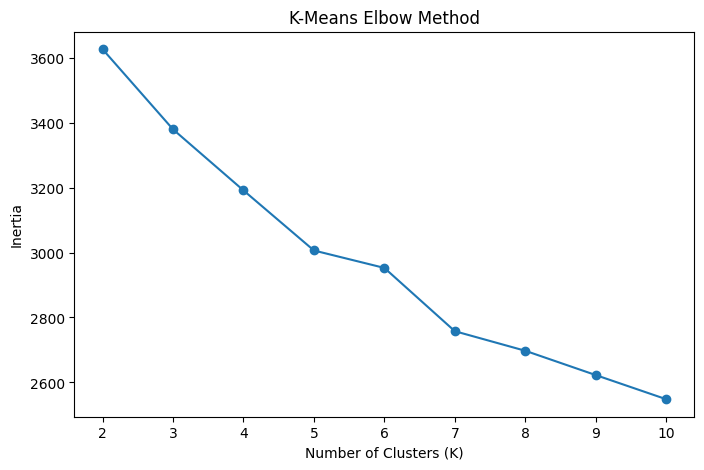

In [76]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.show()

In [77]:
k_values = range(2, 11)

inertia_values = []
silhouette_values = []

In [78]:
for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    

    inertia_values.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_values.append(silhouette_avg)

In [79]:
results = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia_values,
    'Silhouette_Score': silhouette_values
})
results

,K,Inertia,Silhouette_Score
0,2,3625.964288,0.086307
1,3,3379.241951,0.106228
2,4,3191.255472,0.098922
3,5,3006.285370,0.089758
4,6,2952.588946,0.094892
5,7,2757.790511,0.084275
6,8,2697.524611,0.095024
7,9,2622.719156,0.082784
8,10,2548.388807,0.089775


In [80]:
best_k = results.loc[
    results['Silhouette_Score'].idxmax(),
    'K'
]
best_silhouette = results['Silhouette_Score'].max()
print("Best K based on Silhouette Score:", best_k)
print("Highest Silhouette Score:", best_silhouette)

Best K based on Silhouette Score: 3
Highest Silhouette Score: 0.10622815668137058


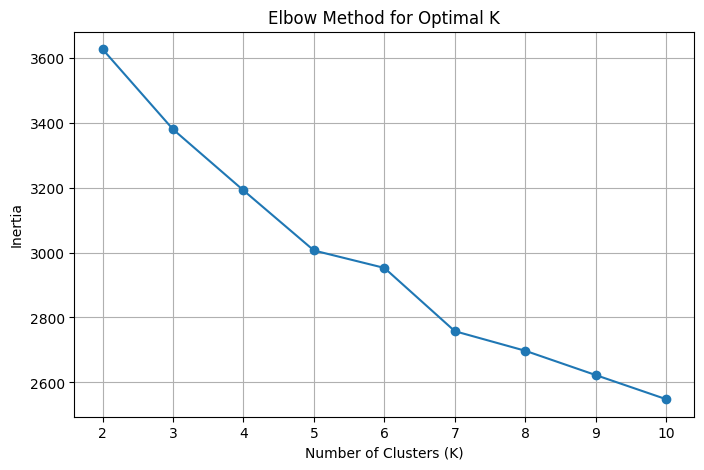

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.xticks(k_values)
plt.grid(True)

plt.show()

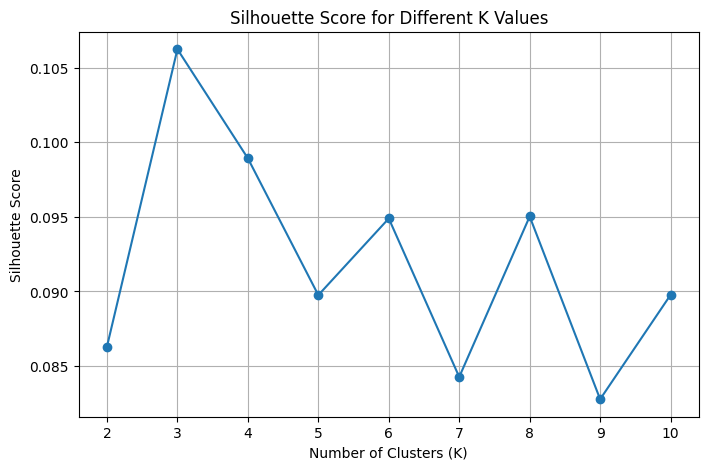

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')

plt.xticks(k_values)
plt.grid(True)

plt.show()

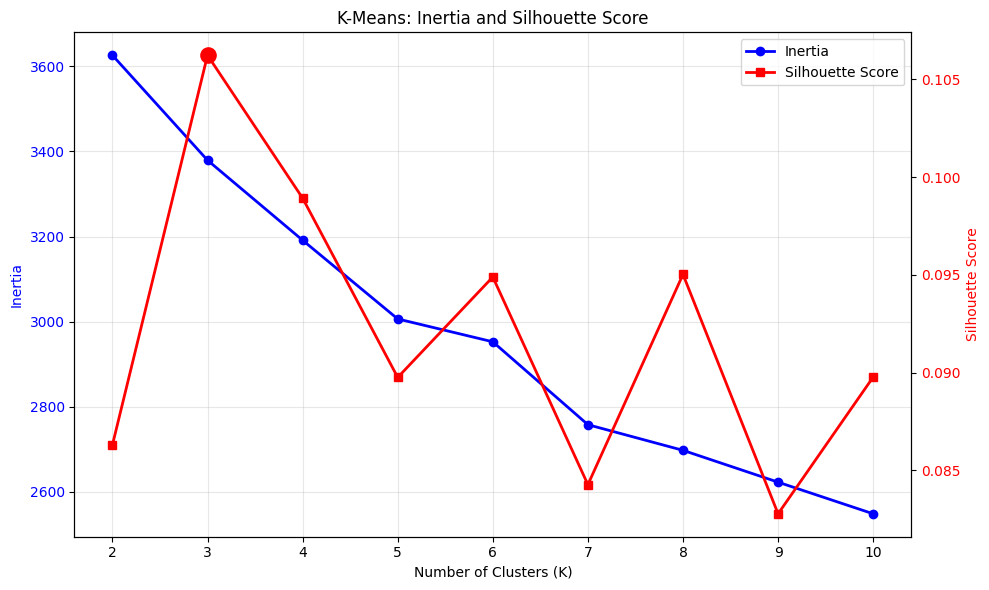

In [83]:
fig, ax1 = plt.subplots(figsize=(10, 6))


line1 = ax1.plot(
    results['K'],
    results['Inertia'],
    marker='o',
    linewidth=2,
    color='blue',
    label='Inertia'
)

ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(results['K'])
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

line2 = ax2.plot(
    results['K'],
    results['Silhouette_Score'],
    marker='s',
    linewidth=2,
    color='red',
    label='Silhouette Score'
)

ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')


best_k = results.loc[
    results['Silhouette_Score'].idxmax(),
    'K'
]

best_score = results['Silhouette_Score'].max()

# Mark best K
ax2.scatter(
    best_k,
    best_score,
    color='red',
    s=120,
    zorder=5
)

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc='upper right'
)

plt.title('K-Means: Inertia and Silhouette Score')

plt.tight_layout()
plt.show()

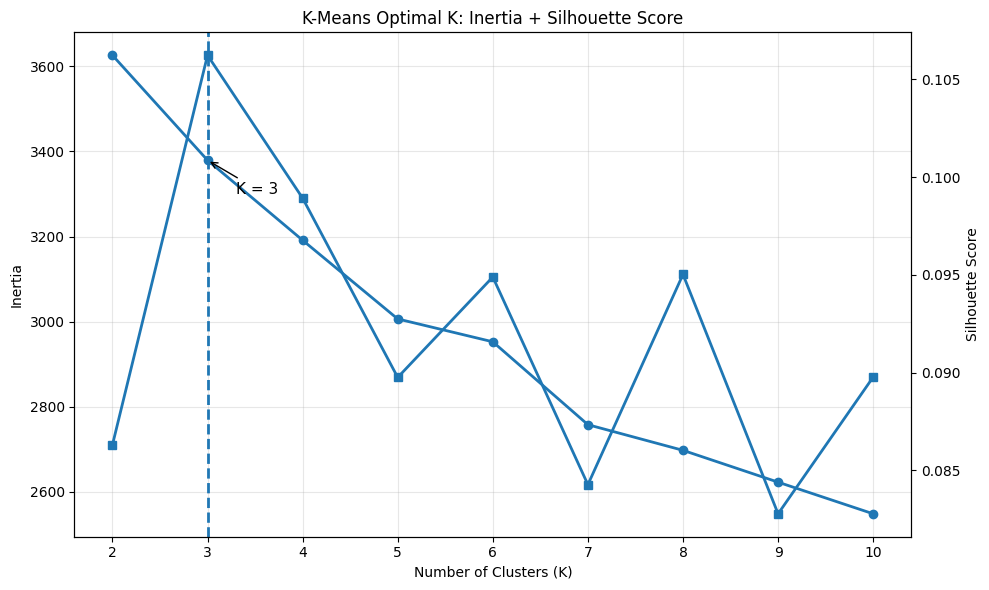

In [84]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Inertia
ax1.plot(
    results['K'],
    results['Inertia'],
    marker='o',
    linewidth=2,
    label='Inertia'
)

ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(results['K'])
ax1.grid(True, alpha=0.3)

# Silhouette
ax2 = ax1.twinx()

ax2.plot(
    results['K'],
    results['Silhouette_Score'],
    marker='s',
    linewidth=2,
    label='Silhouette Score'
)

ax2.set_ylabel('Silhouette Score')

# Mark K = 3
selected_k = 3

ax1.axvline(
    x=selected_k,
    linestyle='--',
    linewidth=2
)

ax1.annotate(
    'K = 3',
    xy=(selected_k, results.loc[
        results['K'] == selected_k, 'Inertia'
    ].iloc[0]),
    xytext=(selected_k + 0.3, 3300),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

plt.title('K-Means Optimal K: Inertia + Silhouette Score')

plt.tight_layout()
plt.show()

- K=3 was selected because it produced the highest silhouette score among the evaluated cluster counts, while the inertia showed the expected decreasing trend. However, the relatively low silhouette score indicates that the customer clusters have considerable overlap.

## K-MEAN

In [85]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_clusters = final_kmeans.fit_predict(X_scaled)

In [86]:
final_kmeans.labels_

array([1, 2, 2, 1, 0, 1, 1, 2, 0, 2, 1, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       2, 1, 1, 0, 2, 2, 2, 1, 1, 1, 2, 0, 1, 1, 2, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 2, 1, 1, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 1, 0, 2, 2, 1, 1,
       2, 1, 2, 1, 0, 0, 1, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1,
       0, 0, 0, 2, 2, 2, 1, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1,
       1, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 2, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 0, 2, 1, 1, 1, 1, 0, 2, 0, 1, 2, 1, 0, 2, 1, 2, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 0, 1, 1, 1, 1, 1, 0, 0, 1, 2,
       0, 1, 1, 1], dtype=int32)

In [87]:
df["Label"] = final_kmeans.labels_

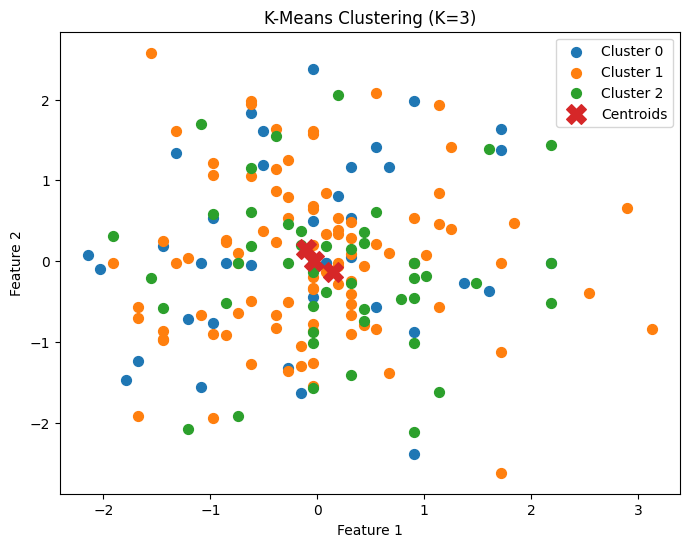

In [88]:
plt.figure(figsize=(8,6))

for cluster in range(3):
    plt.scatter(
        X_scaled[final_clusters == cluster, 0],
        X_scaled[final_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        s=50
    )

plt.scatter(
    final_kmeans.cluster_centers_[:, 0],
    final_kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering (K=3)')
plt.legend()
plt.show()

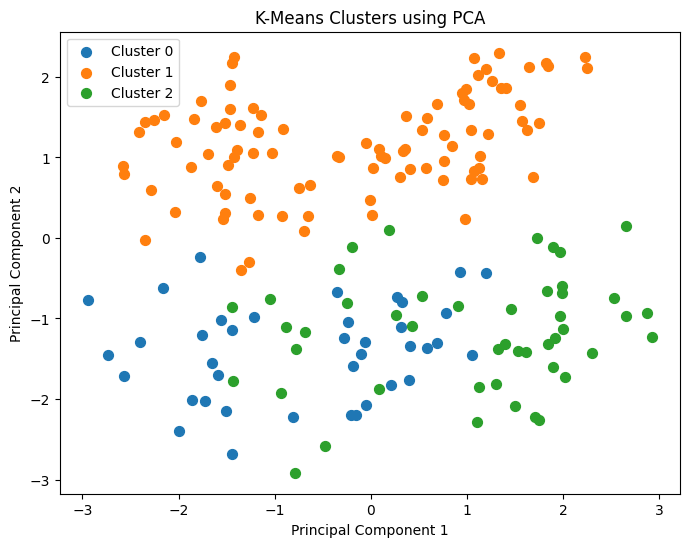

In [89]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for cluster in range(3):
    plt.scatter(
        X_pca[final_clusters == cluster, 0],
        X_pca[final_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        s=50
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters using PCA')
plt.legend()
plt.show()

In [90]:
df_cluster = df.copy()

df_cluster['Cluster'] = final_clusters

df_cluster.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,Label,Cluster
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes,1,1
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes,2,2
2,CUST-1157,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes,2,2
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes,1,1
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes,0,0


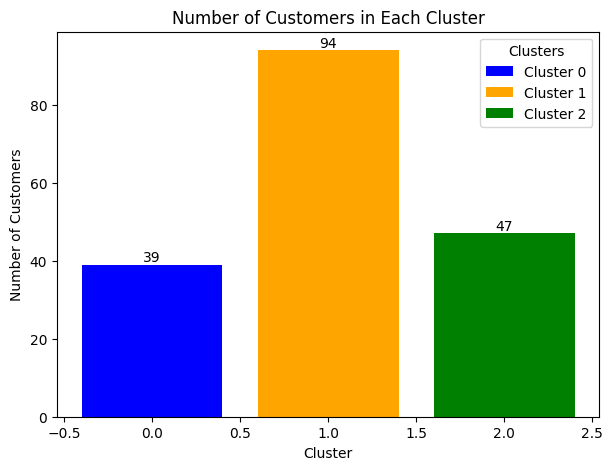

In [91]:
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    cluster_counts.index,
    cluster_counts.values,
    color=['blue', 'orange', 'green']
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')

# Add legend
plt.legend(
    bars,
    [f'Cluster {cluster}' for cluster in cluster_counts.index],
    title='Clusters'
)

# Add values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.show()

In [92]:
final_silhouette = silhouette_score(
    X_scaled,
    final_clusters
)

print("Selected K:", best_k)
print("Final Silhouette Score:", final_silhouette)
print("Final Inertia:", final_kmeans.inertia_)

Selected K: 3
Final Silhouette Score: 0.10622815668137058
Final Inertia: 3379.241950722284


In [93]:
df_cluster["Cluster"].value_counts()

Cluster
1    94
2    47
0    39
Name: count, dtype: int64

In [94]:
df_cluster["Cluster"].value_counts().sort_index()

Cluster
0    39
1    94
2    47
Name: count, dtype: int64

In [95]:
numeric_cols = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

In [96]:
cluster_profile = df_cluster.groupby("Cluster")[numeric_cols].mean()
cluster_profile.round(2)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Cluster,,,,,,,
0,35.41,68425.64,38.87,80.78,2.87,15.85,6.05
1,36.06,65295.74,38.88,71.96,3.11,18.73,6.00
2,37.55,62287.23,37.91,76.06,3.11,20.88,5.04


In [97]:
overall_mean = df_cluster[numeric_cols].mean()

cluster_vs_overall = cluster_profile - overall_mean

cluster_vs_overall.round(2)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Cluster,,,,,,,
0,-0.90,3237.31,0.24,5.83,-0.18,-2.82,0.29
1,-0.25,107.41,0.26,-2.98,0.05,0.06,0.24
2,1.24,-2901.10,-0.71,1.12,0.05,2.21,-0.72


In [98]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Contract_Type"],
    normalize="index"
).round(2) * 100

Contract_Type,1 Year,2 Year,Monthly
Cluster,,,
0,26.0,21.0,54.0
1,32.0,13.0,55.0
2,26.0,9.0,66.0


In [99]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Plan_Type"],
    normalize="index"
).round(2) * 100

Plan_Type,Basic,Premium,Standard
Cluster,,,
0,0.0,100.0,0.0
1,0.0,0.0,100.0
2,100.0,0.0,0.0


In [100]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Payment_Method"],
    normalize="index"
).round(2) * 100

Payment_Method,Bank Transfer,Credit Card,Debit Card,UPI,Unknown
Cluster,,,,,
0,21.0,26.0,28.0,26.0,0.0
1,27.0,27.0,17.0,29.0,1.0
2,30.0,19.0,30.0,21.0,0.0


In [101]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Churn"],
    normalize="index"
).round(2) * 100

Churn,No,Yes
Cluster,,
0,54.0,46.0
1,53.0,47.0
2,32.0,68.0


In [102]:
cluster_names = {
    0: "Premium Light Users",
    1: "Moderate-Usage Support Customers",
    2: "High-Usage Customers"
}

In [103]:
df_cluster["Customer_Segment"] = df_cluster["Cluster"].map(cluster_names)

In [104]:
df_cluster[["Cluster", "Customer_Segment"]].head(20)

,Cluster,Customer_Segment
0,1,Moderate-Usage Support Customers
1,2,High-Usage Customers
2,2,High-Usage Customers
3,1,Moderate-Usage Support Customers
4,0,Premium Light Users
5,1,Moderate-Usage Support Customers
6,1,Moderate-Usage Support Customers
7,2,High-Usage Customers
8,0,Premium Light Users
9,2,High-Usage Customers


In [105]:
df_cluster["Customer_Segment"].value_counts()

Customer_Segment
Moderate-Usage Support Customers    94
High-Usage Customers                47
Premium Light Users                 39
Name: count, dtype: int64

## Cluster Segment Names and Behavior

After applying K-Means clustering with **K = 3**, three customer segments were identified. The names were assigned based on the major behavioral characteristics observed from the average values of each cluster.

### Cluster 0 – Premium Light Users

- **Highest average annual income:** ₹68,425.64
- **Highest average monthly charges:** ₹80.78
- **Lowest data usage:** 15.85 GB
- **Support calls:** 2.87
- **Highest satisfaction score:** 6.05

**Behavior:**

Cluster 0 represents customers with relatively higher annual income and the highest monthly charges among the three clusters. However, they have the lowest data usage. Their satisfaction score is slightly higher than the other clusters.

**Reason for the name:**

- **High-Value** → Highest average income and monthly charges.
- **Low-Usage** → Lowest average data usage.

---

### Cluster 1 – Moderate-Usage Support Customers

- **Annual income:** ₹65,295.74
- **Monthly charges:** ₹71.96
- **Data usage:** 18.73 GB
- **Highest support calls:** 3.11
- **Satisfaction score:** 6.00

**Behavior:**

Cluster 1 represents customers with moderate data usage and moderate income and monthly charges. They have one of the highest levels of support interactions, with an average of 3.11 support calls in the last three months.

**Reason for the name:**

- **Moderate-Usage** → Data usage of 18.73 GB is between Cluster 0 and Cluster 2.
- **Support Customers** → They have a relatively high number of support calls.

---

### Cluster 2 – High-Usage Customers 

- **Lowest average annual income:** ₹62,287.23
- **Monthly charges:** ₹76.06
- **Highest data usage:** 20.88 GB
- **Highest support calls:** 3.11
- **Lowest satisfaction score:** 5.04

**Behavior:**

Cluster 2 represents customers who consume the highest amount of data among the three clusters. They also have the highest support-call level, while their satisfaction score is the lowest.

**Reason for the name:**

- **Heavy-Usage** → Highest average data usage of 20.88 GB.
- **Low-Satisfaction** → Lowest average satisfaction score of 5.04.

---

### Summary

| Cluster | Segment purpose | Key Characteristics |
|:---:|---|---|
| **0** | **High-Value Low-Usage Customers** | Highest income and monthly charges, lowest data usage |
| **1** | **Moderate-Usage Support Customers** | Moderate data usage, relatively high support interactions |
| **2** | **Heavy-Usage Low-Satisfaction Customers** | Highest data usage, highest support calls, lowest satisfaction |

> **Note:** The segment names are descriptive labels based on the numerical characteristics of the clusters. They are not used to create the clusters; they are assigned **after K-Means clustering** to make the clusters easier to interpret.

In [106]:

print("=" * 60)
print("1. CUSTOMER COUNT BY SEGMENT")
print("=" * 60)
print(df_cluster["Customer_Segment"].value_counts())


# 2. Contract Type
print("\n" + "=" * 60)
print("2. CONTRACT TYPE BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Contract_Type"],
        normalize="index"
    ).round(2) * 100
)



# 4. Payment Method
print("\n" + "=" * 60)
print("4. PAYMENT METHOD BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Payment_Method"],
        normalize="index"
    ).round(2) * 100
)


# 5. Region
print("\n" + "=" * 60)
print("5. REGION BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Region"],
        normalize="index"
    ).round(2) * 100
)


# 6. Churn
print("\n" + "=" * 60)
print("6. CHURN BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Churn"],
        normalize="index"
    ).round(2) * 100
)

1. CUSTOMER COUNT BY SEGMENT
Customer_Segment
Moderate-Usage Support Customers    94
High-Usage Customers                47
Premium Light Users                 39
Name: count, dtype: int64

2. CONTRACT TYPE BY SEGMENT (%)
Contract_Type                     1 Year  2 Year  Monthly
Customer_Segment                                         
High-Usage Customers                26.0     9.0     66.0
Moderate-Usage Support Customers    32.0    13.0     55.0
Premium Light Users                 26.0    21.0     54.0

4. PAYMENT METHOD BY SEGMENT (%)
Payment_Method                    Bank Transfer  Credit Card  Debit Card  \
Customer_Segment                                                           
High-Usage Customers                       30.0         19.0        30.0   
Moderate-Usage Support Customers           27.0         27.0        17.0   
Premium Light Users                        21.0         26.0        28.0   

Payment_Method                     UPI  Unknown  
Customer_Segment       

In [107]:
print("\n" + "=" * 60)
print("3. PLAN TYPE BY SEGMENT (%)")
print("=" * 60)
print(
    pd.crosstab(
        df_cluster["Customer_Segment"],
        df_cluster["Plan_Type"],
        normalize="index"
    ).round(2) * 100
)



3. PLAN TYPE BY SEGMENT (%)
Plan_Type                         Basic  Premium  Standard
Customer_Segment                                          
High-Usage Customers              100.0      0.0       0.0
Moderate-Usage Support Customers    0.0      0.0     100.0
Premium Light Users                 0.0    100.0       0.0


### Overall behavior of your 3 segments

##### Premium Light Users

- Premium-plan customers with higher income and charges but comparatively lower data usage. They have the highest proportion of 2-Year contracts among the three segments.

#### Moderate-Usage Support Customers

- The largest customer segment, consisting entirely of Standard-plan customers. They have moderate usage and relatively high support interactions, with a fairly balanced churn distribution.

#### High-Usage Customers

- Basic-plan customers with the highest data usage. They are predominantly on Monthly contracts and have the highest observed churn percentage at 68%.

## Hierarchical

In [108]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

In [109]:
Z = linkage(X_scaled, method="ward")

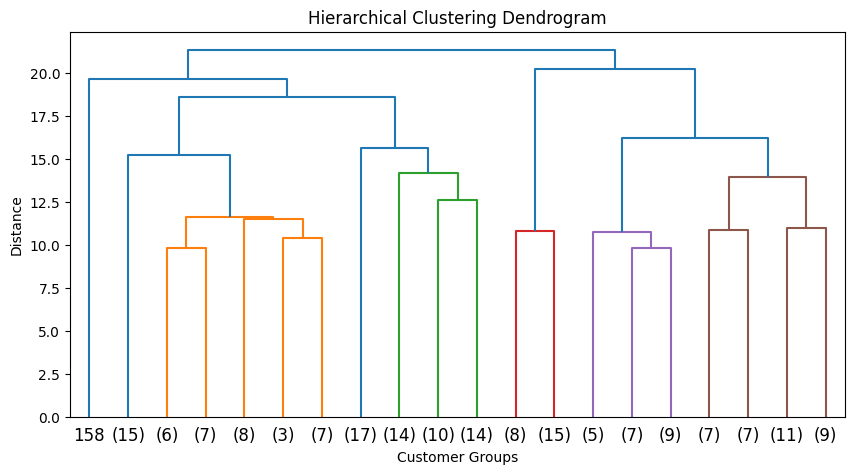

In [110]:
plt.figure(figsize=(10, 5))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.show()

In [111]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

results_hc = []

for k in range(2, 15):
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = hc.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    results_hc.append({
        "K": k,
        "Silhouette_Score": score
    })

hc_results = pd.DataFrame(results_hc)

hc_results

,K,Silhouette_Score
0,2,0.058935
1,3,0.072190
2,4,0.075496
3,5,0.068682
4,6,0.067495
5,7,0.052993
6,8,0.063343
7,9,0.064790
8,10,0.072924
9,11,0.075872


In [112]:
best_k = hc_results.loc[
    hc_results["Silhouette_Score"].idxmax(),
    "K"
]

best_score = hc_results["Silhouette_Score"].max()

print("Best K:", best_k)
print("Highest Silhouette Score:", best_score)

Best K: 14
Highest Silhouette Score: 0.08991112960074459


In [113]:
hc = AgglomerativeClustering(
    n_clusters=14,
    linkage="ward"
)

df_cluster["Hierarchical_Cluster"] = hc.fit_predict(X_scaled)

In [114]:
df_cluster["Hierarchical_Cluster"].value_counts().sort_index()

Hierarchical_Cluster
0     14
1     10
2     23
3     15
4     14
5     21
6     17
7      1
8     14
9      9
10    10
11    13
12     8
13    11
Name: count, dtype: int64

In [115]:
hierarchical_profile = (
    df_cluster
    .groupby("Hierarchical_Cluster")[numeric_cols]
    .mean()
    .round(2)
)

hierarchical_profile

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Hierarchical_Cluster,,,,,,,
0,35.79,58657.14,36.57,87.84,2.64,14.56,5.79
1,38.30,55810.00,41.90,89.38,3.90,21.42,5.90
2,33.52,64013.04,37.43,75.09,3.09,16.64,5.96
3,39.20,69613.33,52.40,81.72,2.67,20.37,6.20
4,36.93,63164.29,34.79,85.14,3.21,14.36,5.29
5,35.48,71438.10,33.71,60.01,3.48,16.07,6.38
6,34.88,62735.29,37.47,63.00,3.06,24.06,6.47
7,31.00,107100.00,38.00,55.24,2.00,20.60,9.00
8,34.43,75807.14,48.21,78.82,4.14,20.02,7.00


In [116]:
hierarchical_names = {
    0: "Heavy-Usage Support Customers",
    1: "Moderate-Usage Customers",
    2: "Balanced Customers",
    3: "Premium High-Income Customers"
}

df_cluster["Hierarchical_Segment"] = (
    df_cluster["Hierarchical_Cluster"].map(hierarchical_names)
)

df_cluster[
    ["Hierarchical_Cluster", "Hierarchical_Segment"]
].head(20)

,Hierarchical_Cluster,Hierarchical_Segment
0,12,NaN
1,1,Moderate-Usage Customers
2,11,NaN
3,6,NaN
4,3,Premium High-Income Customers
5,5,NaN
6,5,NaN
7,3,Premium High-Income Customers
8,4,NaN
9,1,Moderate-Usage Customers


## DBSCAN

In [117]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df_cluster["DBSCAN_Cluster"] = dbscan_labels

print(df_cluster["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1    180
Name: count, dtype: int64


In [118]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Number of clusters:", n_clusters)
print("Number of noise points:", list(dbscan_labels).count(-1))

Number of clusters: 0
Number of noise points: 180


In [119]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score cannot be calculated.


In [120]:


results_dbscan = []

for eps in [4.0, 4.25, 4.5, 4.75, 5.0]:
    for min_samples in [3, 4, 5, 6, 8, 10]:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        # Number of clusters excluding noise (-1)
        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

    
        n_noise = (labels == -1).sum()

    
        noise_percentage = (
            n_noise / len(labels)
        ) * 100

        mask = labels != -1

        if n_clusters >= 2:
            score = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )
        else:
            score = np.nan

        results_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "noise_percentage": round(noise_percentage, 2),
            "silhouette_score": round(score, 6)
                if not np.isnan(score) else np.nan
        })

dbscan_results = pd.DataFrame(results_dbscan)

dbscan_results

,eps,min_samples,clusters,noise_points,noise_percentage,silhouette_score
0,4.00,3,2,61,33.89,0.075333
1,4.00,4,1,69,38.33,NaN
2,4.00,5,1,87,48.33,NaN
3,4.00,6,1,98,54.44,NaN
4,4.00,8,2,116,64.44,0.123885
5,4.00,10,1,137,76.11,NaN
6,4.25,3,2,26,14.44,0.100355
7,4.25,4,1,35,19.44,NaN
8,4.25,5,1,40,22.22,NaN
9,4.25,6,2,49,27.22,0.070129


In [121]:
dbscan_results[
    (dbscan_results["clusters"] >= 2) &
    (dbscan_results['noise_percentage'] <= 20)
].sort_values(
    by="silhouette_score",
    ascending=False
).head(15)

,eps,min_samples,clusters,noise_points,noise_percentage,silhouette_score
6,4.25,3,2,26,14.44,0.100355
15,4.50,6,2,16,8.89,0.090955
14,4.50,5,2,11,6.11,0.071006


In [122]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=4.25,
    min_samples=6
)

df_cluster["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

print(df_cluster["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     49
 0    128
 1      3
Name: count, dtype: int64


In [123]:
dbscan_counts = (
    df_cluster["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

print(dbscan_counts)

DBSCAN_Cluster
-1     49
 0    128
 1      3
Name: count, dtype: int64


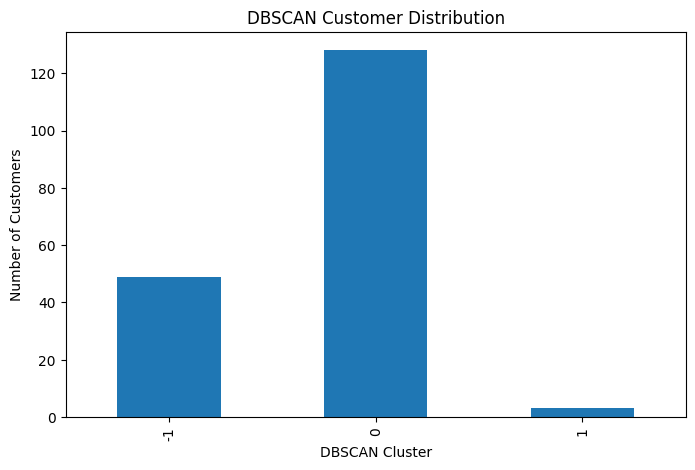

In [124]:
dbscan_counts.plot(
    kind="bar",
    figsize=(8,5),
    title="DBSCAN Customer Distribution"
)

plt.xlabel("DBSCAN Cluster")
plt.ylabel("Number of Customers")
plt.show()

## GMM

In [125]:
from sklearn.mixture import GaussianMixture

In [126]:
gmm_results = []

for k in range(2, 11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = gmm.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    gmm_results.append({
        "K": k,
        "Silhouette_Score": silhouette,
        "BIC": gmm.bic(X_scaled),
        "AIC": gmm.aic(X_scaled)
    })

gmm_results = pd.DataFrame(gmm_results)

gmm_results

,K,Silhouette_Score,BIC,AIC
0,2,0.086307,-1307.473013,-3066.792237
1,3,0.079141,-2584.292495,-5224.867810
2,4,0.084839,-3361.279286,-6883.110693
3,5,0.104569,-2588.485320,-6991.572818
4,6,0.100072,-1278.478098,-6562.821686
5,7,0.083327,-2078.584456,-8244.184135
6,8,0.078405,24.155104,-7022.700665
7,9,0.077317,729.007371,-7199.104490
8,10,0.072599,80.990911,-8728.377040


## Compare

In [130]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

comparison = []


labels_kmeans = df_cluster["Cluster"].values

comparison.append({
    "Algorithm": "K-Means",
    "Clusters": len(np.unique(labels_kmeans)),
    "Noise_%": 0,
    "Silhouette_Score": silhouette_score(
        X_scaled,
        labels_kmeans
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled,
        labels_kmeans
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled,
        labels_kmeans
    )
})



labels_hierarchical = df_cluster["Hierarchical_Cluster"].values

comparison.append({
    "Algorithm": "Hierarchical",
    "Clusters": len(np.unique(labels_hierarchical)),
    "Noise_%": 0,
    "Silhouette_Score": silhouette_score(
        X_scaled,
        labels_hierarchical
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled,
        labels_hierarchical
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled,
        labels_hierarchical
    )
})



labels_dbscan = df_cluster["DBSCAN_Cluster"].values

mask = labels_dbscan != -1

n_clusters_dbscan = len(
    set(labels_dbscan) - {-1}
)

noise_percentage = (
    np.sum(labels_dbscan == -1)
    / len(labels_dbscan)
) * 100

comparison.append({
    "Algorithm": "DBSCAN",
    "Clusters": n_clusters_dbscan,
    "Noise_%": noise_percentage,
    "Silhouette_Score": silhouette_score(
        X_scaled[mask],
        labels_dbscan[mask]
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled[mask],
        labels_dbscan[mask]
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled[mask],
        labels_dbscan[mask]
    )
})



comparison_df = pd.DataFrame(comparison)

comparison_df.round(4)

,Algorithm,Clusters,Noise_%,Silhouette_Score,Calinski_Harabasz,Davies_Bouldin
0,K-Means,3,0.0000,0.1062,15.2097,2.6703
1,Hierarchical,14,0.0000,0.0899,8.9949,1.8669
2,DBSCAN,2,27.2222,0.0701,2.7406,1.6532


In [131]:
comparison_df.style.format({
    "Silhouette_Score": "{:.6f}",
    "Noise_%": "{:.2f}",
    "Calinski_Harabasz": "{:.2f}",
    "Davies_Bouldin": "{:.4f}"
})

,Algorithm,Clusters,Noise_%,Silhouette_Score,Calinski_Harabasz,Davies_Bouldin
0,K-Means,3,0.00,0.106228,15.21,2.6703
1,Hierarchical,14,0.00,0.089911,8.99,1.8669
2,DBSCAN,2,27.22,0.070129,2.74,1.6532


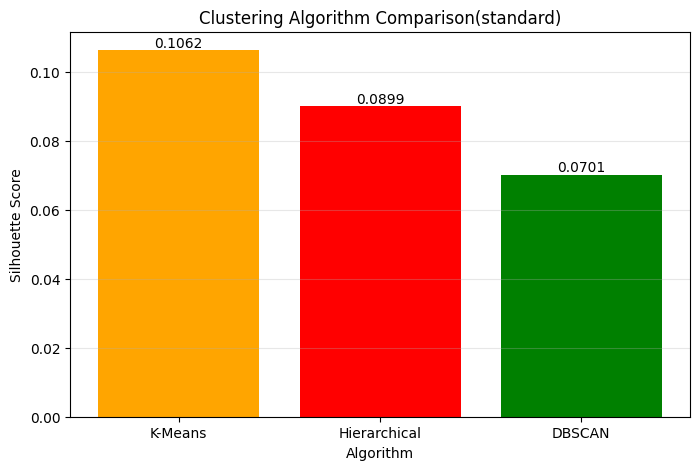

In [133]:
plt.figure(figsize=(8, 5))

colors = ["orange","red","green"]

bars = plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Silhouette_Score"],
    color=colors
)

plt.title("Clustering Algorithm Comparison(standard)")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()